---
title: "《统计学》（*Statistics*）阅读随笔"
author: "KaisMemo"
date: "2026-01-20"
categories: [data analysis, statistics]
---

## 思路沉淀

分析数据之前，应该根据分析目标确定要收集哪些数据。

数据的来源分为三类：

- 主动设计随机对照实验获取的数据

  实验如果涉及到受试者的行为、认知或感官判断，要引入双盲方法。

- 从目标群体中随机抽样获取的数据

  抽样方式有很多，比如简单随机抽样、分层聚集抽样等，目的都是用随机因素代替主观判断。

- 已有数据源的总体数据

  这是现代最常见的场景，比如从各 OLAP 获取数据，或者直接从 Hive、Spark 等分布式存储计算引擎获取数据。

获取到的数据分为定性数据和定量数据。定性数据可以转化为定量数据用以数值方法分析，定量数据又可以分为离散数据和连续数据。

然后先根据每列数据的业务语义思考它的概率分布应该是什么样子，然后实际绘制概率直方图检验自己的判断。检验失败的数据需要考虑是数据质量的问题，还是单纯判断失误。如果数据呈现多峰分布，大概率是有混杂因素，可以分层剔除。

符合正态分布的数据，可以用数据的均值和标准差概括，否则可以使用中位数和百分位数来概括。

需要的话，可以用相关系数检查两个变量之间的相关性并据此做回归预测。

对于抽样数据，一般有两类分析：

- 根据总体估计样本
- 根据样本估计总体

不论哪种分析，应该先建立盒子模型，把总体抽象成一个装着数字卡片的盒子，用这些数字的占比反映总体各部分的占比，把抽样过程抽象为从盒子中有放回或无放回地抽取卡片。根据大数定律，只要样本数量足够，样本的概率分布会非常接近总体各部分的概率分布

根据总体估计样本时，可以用总体的均值和标准差估计样本的期望值和标准误差。根据样本估计总体时，可以用样本的均值和标准差估计总体的均值和标准差，再进一步据此计算样本的期望值和标准误差。最终都会得到一个预测区间，根据概率分布模型（一般是正态分布）得出最终结论。

z 检验主要用于比较样本均值与总体均值，或者两个样本均值之间的差异。适用条件为：

- 总体标准差 $\sigma$ 已知
- 或者总体标准差未知，但样本量较大（通常 $n > 30$），根据中心极限定理，样本标准差可以作为总体标准差的可靠估计
- 数据服从正态分布

t 检验用于样本量较小且总体标准差未知的情况。它是实际研究中最常用的均值比较工具。适用条件为：

- 总体标准差 $\sigma$ 未知。
- 样本量较小（通常 $n < 30$）。
- 数据需服从正态分布或近似正态分布。

t 分布的形态受自由度 ($df$) 影响。当样本量增加时，t 分布会逐渐逼近标准正态分布（z 分布）。

卡方检验关注的是频数（Count）或比例，属于非参数检验。适用对象是定类数据，例如性别（男/女）、颜色（红/黄/蓝）等。主要用于拟合优度检验（实际观测频数是否符合某种理论期望分布）和独立性检验（两个分类变量之间是否存在关联，例如：抽烟是否与患肺癌有关）。

## 第一章：对照实验

设计对照实验时，不要人为划定实验组和对照组，要随机划定，这样可以最大程度避免混杂变量导致的偏差，也就是说，应该尽可能设计随机对照实验。另外，只要实验涉及人的行为、认知或感官判断，双盲就有应用价值。

## 第二章：观察性实验

现实世界中，往往无法主动设计实验，只能被动地观察已经发生的数据，换言之，实验者无法主动控制哪些样本作为实验组，哪些样本作为对照组，样本自身的属性决定了自身是实验组还是对照组，这就是观察性实验。

比如，要观察吸烟是否有害健康，实验者不可能主动找一群人吸十年烟，另一群人则完全隔绝烟。只能观察目前已经在吸烟的人和没在吸烟的人，以此来获取实验数据。

因此，观察性实验相比于对照实验更容易掺入混杂因素，所以，即使你观察到两个变量之间有很强的相关性，也不能认为二者之间存在因果关系。

但是，我们可以通过划分更小更同质的子群体来尽量剥离混杂因素的影响，这个过程也叫控制混杂因素。

另外，由于辛普森悖论的存在，控制混杂因素变得更为必要，且在汇总结果的时候，需要考虑样本量的影响。

> 辛普森悖论是指子群体的统计结果与整体的统计结果由于汇总时的样本权重失衡而出现结论相悖的情况。参考原书 19 页。可以通过引入各个子群体的权重来避免辛普森悖论。

在查看一项研究时，要考虑以下问题：

- 是否存在对照组？
- 是否使用了历史对照组，还是同时期对照组？
- 研究对象是如何被分配到不同试验组的？是研究者控制的（即实验性研究），还是受试者自身的属性决定的（即观察性研究）？
- 如果是实验性研究，分配方式是通过随机机制（即随机对照）实现的，还是取决于研究者的判断？
- 数据是怎么得到的？如果是来自受试者自报的，则需要持怀疑态度。

## 第三章：直方图

当横轴区间不等距或者需要拟合概率密度曲线时，应该使用密度直方图，当横轴等距或者为了通俗易懂时，应该使用频数直方图。

密度直方图纵轴表示每单位所占百分比，横轴表包含一个或多个单位的各个区间。区间数量依赖经验判断，但是一般在 10~15 个。各块的面积代表对应区间所占的百分比。横轴的间距应该切实体现数值的差距。所有块的面积相加应该等于 100%。

数据可以分为定性数据和定量数据。定性数据可以通过某种方式转化为定量数据，而定量数据又可以分为：

- 连续变量：指可以连续无间隔变化的变量。
- 离散变量：只能以固定间隔变化的变量。

基于两类变量绘制直方图时需要注意，如果是连续变量，需要思考区间划分的数量和区间的开闭性。对于离散变量，可以简单用固定间隔的中心点作为离散点使用。

对于可能存在混杂变量的数据，要先分层（或者分维度）绘图，把混杂因素的影响隔离开。有些人会使用交叉表来表示，但这种方式不是很直观，人很容易会忽略某些数据。

## 第四章：均值和标准差

直方图可用于对大量数据进行汇总。通常，还可以进行更为简要的汇总：仅给出直方图的中心位置以及围绕中心位置的分布范围：平均值和中位数常用于确定中心位置。标准差和四分位距可以衡量数据围绕平均值的分布范围。

虽然均值有很强的概括性，但在很多情况下会导致信息丢失，比如，直方图的分布不是单峰分布。

横向研究是指同一时间点对不同样本的研究，纵向研究是指不同时间点对同一样本的研究，也叫同期群研究。

如果直方图围绕某个值呈对称分布，那么这个值就等于平均值。此外，直方图下方的面积的一半位于该值的左侧，另一半则位于右侧。如果不对称，那么平均值会在使得两侧平衡的地方。但是对于中位数，它始终把左右两侧的面积对半分。

右长尾会导致均值右移，使其大于中位数，左长尾会导致均值左移，使其小于中位数，正态的情况下，均值和中位数差不多。

![mean_median_mode](./img/mean_median_mode.jpg)

均方根也叫 R.M.S（Root Mean Square），用来衡量数据围绕零点的分散程度，计算步骤为：

1. 取所有数据的平方，消除正负号的影响
2. 计算平方后的均值，得到平均偏差
3. 将平方后的均值开方，还原因为平方导致的量纲丢失和偏差扩大

公式：$\sqrt{\frac{1}{n} \sum x_i^2}$

标准差也叫 SD（Standard Deviation），用来衡量数据围绕均值的分散程度，计算步骤为：

1. 取所有数据与均值的距离的平方，消除正负偏差的影响
2. 计算平方后的均值，得到平均偏差
3. 将平方后的均值开方，还原因为平方导致的量纲丢失和偏差扩大

公式：$\sqrt{\frac{1}{n} \sum (x_i - \bar{x})^2}$ 或者 $SD = \sqrt{\text{average of (entries}^2) - (\text{average of entries})^2}$

后者可以用前者推导而来，通常来说，后者的更好算一些。后者的计算步骤可以理解为：

1. 取所有数据的平方，消除正负偏差的影响，再取均值，得到距离零点的平均偏差
2. 取所有数据的均值的平方，消除正负偏差的影响
3. 用 1 - 2，在距离零点的平均偏差中排除均值那部分的偏差，仅保留距离均值的偏差
4. 开方，还原因为平方导致的量纲丢失和偏差扩大

其中，$\frac{1}{n} \sum (x_i - \bar{x})^2$ 是方差，$(x_i - \bar{x})$ 是离差。

标准差是非常有用的，一个经验法则是：数据中大约 68% 的数据距离均值的偏差不会超过一个 SD，大约 95% 的数据距离均值的偏差不会超过两个 SD。不过这个经验法则不是 100% 适用的，只适用于正态分布的数据。

有些计算器的 SD 不是我们这里讨论的标准差，而是样本标准差 SD+，可以用这个公式互转：$\text{SD} = \sqrt{\frac{n-1}{n}} \times \text{SD}^+$，要确定计算器给出的标准差是哪种，可以用用它算算 1,-1 的标准差，如果是 1，那就是 SD，如果是 1.41.. 那就是 SD+。

## 第五章：数据的正态逼近

标准正态曲线方程：$f(x) = \frac{1}{\sqrt{2\pi}} e^{-\frac{x^2}{2}}$

![normal_distribution](./img/normal_distribution.jpg)

该图表的几个特征将非常重要：

- 该图表关于 0 点对称：位于 0 右侧的曲线部分与左侧的曲线部分是镜像关系。
- 曲线下的总面积等于 100%。（面积以百分比表示，因为纵轴是密度。）
- 曲线始终位于横轴之上。

图中看起来这个曲线似乎在 3 到 4 之间停止，但这只是因为曲线在那里变得很低。只有约 6/100,000 的面积在 -4 到 4 的区间之外。

找出正态曲线图中特定数值之间的区域将会很有帮助。例如：

- 正态曲线在 -1 到 +1 之间的区域约占 68%
- 在 -2 到 +2 之间的区域约占 95%
- 正态曲线在 -3 到 +3 之间的区域约占 99.7%

这就是正态曲线著名的“68-95-99.7” 原则，如果直方图能够很好地拟合正态曲线，那么这个规则对直方图也是适用的。对于直方图拟合的目标正态曲线来说，一个标准单位就是直方图的一个 SD。对于这样的直方图来说，用均值和标准差就可以很好地概括所有数据。

对于如下图这样的明显不符合正态曲线的数据，一般用百分位数来概括。

![income](./img/income.png)

![percentile](./img/percentile.png)

其中 50 百分位数就是中位数，一般用 75 百分位和 25 百分位的差值表示百分位距。对于存在偏态长尾特征的数据，一般用这两个值表示中心位置和分散程度。

不论数据是否拟合正态曲线，都可以用中位数和百分位数来概括，只有拟合正态曲线的数据，才可以用均值和标准差来概括。

如果在列表中的每个元素上都加上相同的数值，那么这个数值就会被加到平均值中；而标准差则不会发生变化。（与平均值的偏差不会改变，因为加上的常数会抵消掉这一影响。）此外，如果将列表中的每个元素都乘以同一个数，那么平均值和标准差就会分别乘以这个数。有一个例外情况：如果这个常数乘数是负数，那么在将其应用于标准差之前，要先去掉其符号。

## 第六章：测量误差

理想情况下，对同一个事物的反复测量会得到相同的结果，但现实世界中，由于偶然误差的存在，结果并不总是相同的。没有人知道偶然误差是从哪里来的。

一系列重复测量结果的标准差可以反映单次测量的偶然误差的大小。也就是说：测量结果 = 精确结果 + 偶然误差。可以推断，偶然误差的标准差应该严格等于测量结构的标准差。

如果你的直方图看着像正态分布，但分布在一个 SD 范围内的数值与 68% 相距甚远，那么你可能需要剔除一部分异常值，通常是那些超出三个 SD 的值。

另外一种误差是系统误差，也叫偏差，这种误差与偶然误差的区别在于，偶然误差对测量结果的影响可正可负，可大可小，而系统误差对所有测量结果的影响都是同一方向相同大小的。

所以更进一步地：测量结果 = 精确结果 + 偶然误差 + 偏差。

偏差往往是人为引入的，比如卖菜的摊主用此贴吸秤，让卖出去的克重比实际的克重更重，收更多钱。

没有偏差的的情况下，在长期反复测量过程中，多次偶然误差会逐渐相互抵消，使得最终的测量结果的均值接近实际的真实值，而存在偏差的情况下，会使得这个值仍旧偏离真实值。所以我们无法通过重复测量来得到偏差大小。

## 第七章：绘制点和线

小学数学绘图。

## 第八章：相关性

相关（Correlation）主要用于衡量两个变量之间线性关系的强度和方向。它不涉及因果关系，只描述变量是否“一起变动”。

对于存在相关性的变量，一般会选择其中一个作为自变量，另一个作为因变量，语义是：自变量对因变量产生了影响，但是自变量和因变量的选择完全是因场景而异的，比如在探究身高遗传的影响时，可能会用父亲的身高作为自变量，孩子的身高作为因变量，但是在探究从孩子身高反推父亲身高的场景时，孩子身高是自变量，父亲身高是因变量。

可以绘制散点图来观察两个变量的大体相关情况。

与直方图一样，散点图通常也会以一种方式来概括：

- x 轴的均值和 2SD
- y 轴的均值和 2SD
- x 和 y 的相关系数 r

我们也可以说，两个变量之间的关系可以用上面这些指标概括。

![scatter_gram](./img/scatter_gram.png)

r 从理论上一定在 -1~1 之间，正负号代表相关的方向，绝对值越大代表两个变量相关性越强。但是在社会研究中，r 一般会落在 0.3~0.7 之间。

r = 0.8 并不意味着 80% 的数据点围绕着一条直线分布，也不意味着它的相关性是 r = 0.4 的两倍。

从技术上讲，如果两个变量的任意一个标准差为 0，就没有办法定义相关系数，因为 0 代表不变。

散点图的散点一般会分布在 SD Line 附近，SD Line 绘制方法如图：

![sd_line](./img/sd_line.png)

<img src="./img/sd_line_sample.png" alt="sd_line_sample" style="zoom:50%;" />

虚线就是 SD Line。

相关系数的计算方法为：$r = \frac{\sum z_xz_y}{n} = \frac{Cov(x,y)}{SD(x)SD(y)}$

标准单位就是原始值偏离均值的标准差数量，也叫 z 分数：$z = \frac{X - \mu}{\sigma}$。

z 分数的计算过程决定了 z 分数的标准差一定为 $1$：

- 假设原始标准差为 $\text{SD}(X) = \sigma$
- 平移不影响标准差，所以 $\text{SD}(x - \bar{x}) = \text{SD}(X) = \sigma$
- 把原始数据整体缩小 $\sigma$ 倍，会导致标准差缩小 $|\sigma|$ 倍，所以 $\text{SD}(\frac{x - \bar{x}}{\sigma}) = \frac{\text{SD}(X)}{|\sigma|} = \frac{\sigma}{\sigma} = 1$

那为什么 r 可以代表两个变量的相关性呢？

- 对于公式：$r = \frac{\sum z_xz_y}{n}$

  - 取 z 分数一方面是为了消除量纲，让量纲不一致的两个变量能够相互比较；另一方面是为了把数值波动用 SD 归一化，在一个固定的空间内衡量波动的大小。

  - 取乘积是为了反映两个变量变化的方向和大小，同向为正，反向为负，

    > z 分数的方差为 1 和 r 计算方式决定了 r 的取值范围是 $[-1, 1]$

  - 取均值是为了排除样本量的影响，避免样本量越大，值越大的情况，这样就没有可比性了

- 对于公式：$r = \frac{Cov(x,y)}{SD(x)SD(y)}$

  - 取协方差表示两个变量的波动的方向和大小，同向为正，反向为负。但是，协方差的数值受原始变量单位的影响。例如，将身高单位从“米”改为“厘米”，协方差会瞬间扩大 100 倍。这使得我们无法仅凭协方差的大小来判断相关性的强弱。
  - 标准差的乘积代表 $x$ 和 $y$ 构成的波动域，二维的情况下，它代表一个面积为 $SD(x)SD(y)$ 的矩形。
  - 用协方差除以标准差的乘积时，实际上是在做量纲消除和归一化，代表在所有的波动中，有多少比例是由两个变量的“同步线性变化”引起的，几何意义上，可以理解为将 $Cov(x,y)$ 构成的波动矩形缩放到 $SD(x)SD(y)$ 的构成的波动范围矩形中后，波动矩形所占的比例。

  也就是说，两个公式反映了做同一件事情的不同顺序，具体而言，就是做量纲消除和归一化的时机不同。

另外，r 不会随着量纲的变化而变化，意思是，r 不会因为 x 轴或者 y 轴的数值统一添加乘除某个常数就发生变化，甚至直接交换 x 轴和 y 轴也不会使 r 发生变化。

需要注意，r 并不能反映散点围绕标准差线的聚集程度，SD 才可以。下图的 r 都是 0.7，但是上面的图 SD 更小。

<img src="./img/same_r_diff_sd.png" alt="same_r_diff_sd" style="zoom:50%;" />

$r$ 接近 1（或 -1）时，散点紧密围绕 SD 线分布，呈现纤细的椭圆，典型点到 SD 线的垂直距离远小于垂直 SD。

$r$ 接近 0 时，散点分布趋于圆形或无规则云团，典型点到 SD 线的垂直距离接近垂直 SD。

这个距离可以用一个公式来预估：$\sqrt{2(|1 - r|)} \times SD_{vertical}$

如果相关系数为 0.95，那么带入公式可以算到这个距离约为 0.3 倍的 $SD_{vertical}$

<img src="./img/r_95.png" alt="r_95" style="zoom:50%;" />

并不是所有数据的相关性都可以用 r 来衡量，比如对于存在明显异常值和非线性相关的情况。

![not_fit_r](./img/not_fit_r.png)

统计学中有一个重要陷阱：生态相关（Ecological Correlation）。简单来说，当我们用群体（如国家、州、学校）的平均数据来推断个体之间的关系时，往往会夸大相关性的强度。

- 个体层面： 在 2005 年的调查中，25-64 岁男性的收入与教育水平的相关系数约为 **$r \approx 0.42$**。这说明两者有正相关，但并不算极强。
- 群体层面： 如果按“州”计算平均受教育程度和平均收入，这 51 个点的相关系数飙升到了 **$r \approx 0.70$**。

出现这种现象的原因是，群体层面的聚合数据抹去了个体之间的差异，导致信息失真。

左图展示了A、B、C三个州内每个人的分布。可以看到，虽然整体趋势向上，但每个州内部的数据点非常分散。这种分散性降低了相关系数。当我们将每个州缩减为一个点（平均值点）时，原本州内部的所有波动、差异和“杂音”都被消除了。抹去差异后，剩下的平均点往往会排列得更接近一条直线。这给人一种“教育与收入关系极为紧密”的错觉，但实际上它掩盖了个体之间的巨大差异。

![eco_err](./img/eco_err.png)

这种现象导致的逻辑错误被称为“生态谬误”。其核心逻辑陷阱是：认为群体表现出的特征必然适用于该群体内的每一个体。即使州层面的相关性是 1，也不代表该州内受教育程度最高的人一定是收入最高的人。如果直接用“群体平均值”的相关性来推测个体的行为，会显著高估相关强度，导致错误的因果判断。

但是，不论如何，相关性不能等同于因果性。即使两个变量相关性很强，也不能说两个变量存在因果关系。

## 第十章：回归

回归描述了一个变量如何跟随另一个变量变化。

假设身高和体重的相关系数 r 为 0.4，这意味着：

- 1 单位的身高增长预期会导致平均 0.4 单位的体重增长
- 1 单位的体重增长预期会导致平均 0.4 单位的身高增长

这两个结论看似矛盾，因为从代数变换的角度讲，如果 1 单位的身高增长导致 0.4 单位平均体重增长，那么 1 单位的体重增长应该导致 2.5 单位的平均身高增长。

并非如此的原因在于：回归线并不是描述变量之间绝对的物理等式，而是描述在给定某个条件下的“平均表现”。也就是说，相关系数是对称的，但是回归线是有方向的。用于 x 预测 y 的回归线不能用于 y 预测 x，反之同理。

回归线的公式为：$\hat{y} - \bar{y} = \beta(x - \bar{x})$，其中：$\beta =  r\frac{SD(y)}{SD(x)} = \frac{Cov(x,y)}{Var(x)}$，这可以用最小二乘法推导得来。

> 不同于 r 的正向构建，回归线的斜率是以残差平方和最小的目标逆向推导来的。

如何理解这两个不同的公式呢？

- $\beta =  r\frac{SD(y)}{SD(x)}$ 表示 1 个标准差的 $x$ 变化预期会导致  r 个标准差的 $y$ 变化。

- $\beta = \frac{Cov(x,y)}{Var(x)}$ 表示在原始物理单位下，变量 $x$ 每变动 1 个单位，预期变量 $y$ 会随之产生的平均变动量，几何意义上，可以理解为将 $Cov(x,y)$ 构成的波动矩形缩放到 $Var(x)$ 的构成的 $x$ 的波动范围正方形中后，波动矩形所占的比例，换言之， 就是看 $x$ 自身每单位的波动中，有多少比例转化为了 $y$ 的同步波动。

<img src="./img/regression_method.png" alt="regression_method" style="zoom:50%;" />

通常情况下，如果你有大量的原始散点数据 $(x, y)$，你可以直接拟合出一条回归线。但有时为了简化，我们会先把具有相同 $x$ 值的数据归为一组，计算出每一组的 $y$ 平均值，然后对这些“平均值点”进行回归。

在线性相关时，均值回归线是均值图的线性简化，如果均值构成一条直线，那么这条线本身就是均值回归线。

<img src="./img/avg_line.png" alt="avg_line" style="zoom:50%;" />

非线性相关时，均值回归线会过度平滑，导致非线性相关的信息丢失，此时使用直接用均值图会更好一些。

<img src="./img/non_linear_regression_line.png" alt="non_linear_regression_line" style="zoom:50%;" />

如果你直接对平均值图中的点进行回归，而不考虑每个点背后的样本量，那么“只有 2 个人的组”和“有 68 个人的组”对回归线的影响力是一样的，这会导致偏差。换言之，只要在对“平均值点”进行回归时，根据每一组包含的原始样本数量进行“加权”，那么得到的结果与直接对所有原始数据进行回归是一模一样的。

通过回归方程计算出的百分位数，预测的是中位数排名，而不是平均排名。

当你试图通过变量 A 预测变量 B 时，你必须根据 A 与 B 之间的相关性强度，对预测结果进行“打折”（向中位数收缩）。相关性越弱，你的预测就越应该接近中位数，而不是跟随已知信息跑偏。这种现象叫做“均值回归”。

在几乎所有的重测实验中，第一次测试成绩最差的那一组在第二次测试中平均会有一定程度的提升，而成绩最好的那一组则平均会有所下降。这就是所谓的“回归效应”。认为回归效应一定是由于某些重要的因素造成的，而非仅仅是围绕直线的分布情况所致，这种观点就是回归谬误。

## 第十一章：回归的均方根误差

实际值和预测值之间的差值是回归误差。

回归的均方根误差可以用来衡量回归预测的整体偏差程度：$\text{R.M.S Error} = \sqrt{\frac{\sum (x - \hat x)^2}{n}}$

均方根误差与回归线的关系，就如同标准差与平均值的关系。例如，在散点图中，大约 68% 的点会在回归线的一个均方根误差范围内；大约 95% 的点会在两个均方根误差范围内。这一经验法则适用于许多数据集，但并非所有数据集都适用。

![rms_error_in_percent](./img/rms_error_in_percent.png)

对于使用均值作为基线的预测方法来说，它的均方根误差就是 $y$ 的标准差，一般来说，回归预测的均方根误差更小一些，二者之间存在以下关系：$\text{R.M.S Error of Regression} = \sqrt{1-r^2}SD(y)$，这个可以通过数学推导得到。这表示总误差 $Var(y)$ 中，有 $r^2$ 比例的误差是由 $x$ 的线性变动导致的，仍有 $1-r^2$ 比例的误差无法解释。在二元正态分布的数据中，这个公式可以用来预测新数据集的 SD，进而得出新数据集的正态分布形状。

 对于非线性相关的数据集，也不是没有处理办法：

在绘制好回归线之后，可以用残差图检查数据的分布趋势，你很容易能发现非线性或者异方差趋势。对于这种数据集，直接在原始数据的基础上进行回归分析的出的结果是不合适的，可以使用“取对数”的处理方式。以下是适用取对数处理的几种具体情况：

- 数据呈现异方差性

  当数据呈现“散开”的趋势时，即自变量 $x$ 增加，因变量 $y$ 的变异性（方差）也随之增大。在散点图上，数据点形成一个“喇叭口”或“扇形”。取对数可以压缩大数值之间的间距，使高数值区域的波动变小，从而使残差的方差趋于稳定（同方差性）。

- 右偏分布

  当数据的大部分数值集中在低端，而存在少数极大的数值（长尾在右侧）时。收入分布、人口数量、生物体内的化学物质浓度。取对数能将右偏分布拉回到接近正态分布，这是许多参数统计检验（如 t 检验、线性回归）的前提要求。

- 指数增长或乘法关系

  如果变量 $y$ 随着 $x$ 的增加呈指数级增长，或者变量之间的关系是乘法而非加法。若 $y = a \cdot e^{bx}$，取对数后变为 $\ln(y) = \ln(a) + bx$。取对数可以将复杂的指数曲线转变为线性直线，方便使用线性回归模型进行拟合。

- 跨越多个数量级的数据

  当观测值的范围极大（例如从 1 到 1,000,000），直接绘图会导致小数值点全部挤在一起，无法观察趋势。取对数可以将数据转换到对数尺度，使不同数量级的数据在同一张图上具有可比性。

虽然取对数很有用，但它并不是万能的：

- 对数函数在 $x \le 0$ 时无定义。如果数据包含 $0$，通常需要加一个常数（如 $\ln(y + 1)$），但这会改变数据的统计特性。
- 取对数后，斜率 $\beta$ 的物理含义发生了变化。在双对数模型中，$\beta$ 表示弹性（即 $x$ 变化 $1\%$ 时，$y$ 平均变化的百分比），而不再是绝对数值单位的变化。

## 第十二章：回归线

高斯将观测误差视为一种“损失”。在数学建模中，需要通过一个函数来量化观测值与其真实值之间的偏离程度。

- 高斯的方案： 采用误差的平方，即 $L(e) = e^2$。

- 拉普拉斯的方案： 采用误差的绝对值，即 $L(e) = |e|$。

高斯非常客观地指出，无论是他的平方项还是拉普拉斯的绝对值项，在物理本质上都是一种人为的设定。没有一种绝对的理论可以证明哪种损失函数是“真理”，选择平方更多是出于数学计算的便利性以及它在统计推断中的优良性质。

<img src="./img/gause_said_error.png" alt="gause_said_error" style="zoom:50%;" />

如果你进行的是观察性研究，那么回归线只能描述你所观察到的数据。这条线不能用于预测干预措施的效果。还有一种预测失效的情况是两个变量非线性相关。

用最小二乘法得到值，在对照实验中叫最小二乘估计值，在其他观察性实验的领域中，叫回归值。

在任何散点图上都可以绘制一条回归线。然而，有两个问题需要考虑：

- 变量之间是否存在非线性关联？

  如果有这种关联，那么这条回归线可能会非常误导人。即使这种关联看起来是线性的，

- 回归分析是否合理？

  这个问题更难回答。要回答这个问题需要对产生数据的机制有一定的理解。如果这种机制不被理解，绘制一条直线可能会在学术上造成灾难性的后果。换言之，即便统计数据（如相关系数）非常完美，如果背后的逻辑机理错误，回归分析也是没有意义的。

比如，一个研究者不知道面积公式，错误地认为“面积取决于周长”。他测量了 20 个长方形，发现面积和周长的相关系数高达 0.98（极强正相关）。研究者因此得到了一个回归方程：$\text{area} = (1.60 \text{ inches}) \times (\text{perimeter}) - 10.51 \text{ square inches}$。虽然在统计学上这个方程对这 20 个样本预测得非常准，但在几何学上它是错误的。对于周长相同的不同长方形，其面积可以完全不同；面积是由长和宽的乘积决定的（$A = L \times W$），而不是由周长（$P = 2L + 2W$）线性决定的。

再次强调：在做回归分析之前，先思考变量之间的因果逻辑是否通顺，不要被漂亮的统计数字蒙蔽。高相关性可能只是因为样本选择的局限性导致的巧合，并不能证明变量之间存在真实的决定关系。每次做完回归线，都应该用残差图验证两个变量的线性关系。

## 第十三章：什么是概率

“Chance” 这个词在不同的语境下的含义不一样：

- 如果是在讨论数据波动的原因，翻译为 “偶然性”。
- 如果是在讨论假设检验的结果，翻译为 “机遇”。
- 如果是在描述具体的数值大小，翻译 “概率” 或 “可能性”。

关于什么是概率，目前没有一个公认的理论定义。这本书用的是“频率理论”解释的概率，适用于在相同条件下反复进行独立测试的场景。在该理论下，“某一事件发生的概率”指的是，在基本过程不断重复、独立进行且处于相同条件下时，该事件预期发生的次数所占的百分比。

换言之，如果你有 45% 的概率赢游戏，那可能意味着你 45% 的时间在赢游戏，55% 的时间在输游戏。某件事情发生的概率等于 100% 减去其对立事件发生的概率。

事件 A 发生的概率可以表示为：$\text{P}(\text{事件 A})$

条件概率表示在给定条件下，一件事情发生的概率，比如在事件 A 发生的情况下，事件 B 发生的概率：$\text{P}(\text{事件 A} | \text{事件 B})$，其中的 “$|$” 的意思是 “given”（给定）。

可以用乘法法则计算两件事情同时发生的概率：第一件事发生的概率乘以第二件事发生的概率。

如果事件 A 的发生对事件 B 的发生概率没有影响，那么我们就说这两件事情是互相独立的。典型的场景就是有放回地抽扑克牌，不论第一张牌抽出多少，都对第二张牌抽出的概率没有影响。

再次强调，计算多个事件共同发生的概率是，一定要考察子事件之间的独立性。

## 第十四章：深入概率

试图计算概率前，列出这个事件所有可能的结果或者几个典型结果会很有帮助。

当一件事情的发生会阻止另一件事情发生时，我们说这两件事情是互斥的，互斥事件是高度依赖其对立事件的非独立事件。

互斥的两个事件，至少发生一个的概率是两个事件各自发生的概率的加和，这就是加法法则。

如果直接计算一个事件发生的概率很困难，可以试着计算其对立事件的概率，然后用 100% 减去它。

## 第十五章：二项式公式

二项式公式可以回答如下所示的问题：

- 一枚硬币投掷四次。出现恰好一次正面的概率是多少？
- 一颗骰子掷十次。出现恰好三次“A”（通常指点数为1）的概率是多少？
- 一个盒子里有一个红球和九个绿球。随机进行五次有放回的抽取。抽到恰好两个红球的概率是多少？

以红球和绿球的例子为例：

由于是有放回地抽取，所以每次抽取互为独立事件，假设我们要计算抽出“R R G G G” 的概率，可以用乘法公式：$\frac{1}{10} \times \frac{1}{10} \times \frac{9}{10} \times \frac{9}{10} \times \frac{9}{10} = (\frac{1}{10})^2(\frac{9}{10})^3$。

但“R R G G G” 并不是“抽出恰好两个红球”的唯一情况，其他还有类似“R G R G G”、“R G G R G” 等，每五次的抽取结果是互斥事件，我们可以把恰好包含两个红球的所有情况的概率相加。

而恰好包含两个红球的所有情况一共有 $\text{C}_5^2 = \text{C}_5^3 = \frac{5!}{2!3!}$种。这个公式被称为二项式系数。

为什么有这么多种呢？

如果我们假设这 5 个字母都是互不相同的（比如 $R_1, R_2, G_1, G_2, G_3$），那么第一位有 5 种选择，第二位有 4 种，以此类推，总共有 120 种排列方式。由于实际上 R 之间是没有区别的，G 之间也是没有区别的，我们需要除以它们内部排列产生的“重复项，$2!$ 是 2 个 R 的全排列，$3!$ 是 3 个 G 的全排列。

更一般地，在 $n$ 次重复独立实验中，一个事件恰好发生 $k$ 次的概率为：$\frac{n!}{k!(n-k)!}p^k(1-p)^{n-k}$，其中，$p$ 为单次实验中事件发生的概率。

数学家们一般把二项式系数 $\frac{n!}{k!(n-k)!}$ 写作 $\binom{n}{k}$，读作“n choose k”，也就是 n 中选 k。

## 第十六章：大数定律

以抛硬币为例，大数定律不保证随着试验次数的增加，人头朝上的次数一定会更接近总抛掷次数的一半，不如说，会越来越远离总抛掷次数的一半，但是，从百分比上来看，人头朝上所占的百分比却会越来越接近 50%。换言之，绝对误差在增加但百分比误差在减少。

你不能因为前四次都是人头朝上，就认为下次人头朝下的概率会升高。概率都是一样的，都是 50%。

<img src="./img/coin_toss_table.png" alt="coin_toss_table" style="zoom:50%;" />

<img src="./img/coin_toss_count.png" alt="image-20260216173139731" style="zoom:50%;" />

<img src="./img/coin_toss_percnet.jpg" alt="coin_toss_percnet" style="zoom:50%;" />

可以建立盒子模型来评估观测结果会在多大程度上受到偶然因素的影响。主要分为两步：

1. 把研究过程类比成从盒子中抽取随机数字
2. 把你想要评估的偶然变异性与盒子中抽取的数字总和联系起来

根据已知问题建立盒子模型时，需要考虑三个问题：

- 盒子里面有几种数字
- 每种数字有多少张
- 抽取几次

盒子模型的目的是为了分析随机变异性，这种变异性在赌博娱乐场中最明显。因此以轮盘赌为例。

内华达式的轮盘共有 38 个球槽。其中一个标记为 0，另一个标记为 00，其余的球槽标记为 1 到 36。庄荷转动轮盘并向其掷入一个小球。小球落入这 38 个球槽中任何一个的概率都是相等的。在小球落定之前，玩家可以在赌桌上进行投注。一种投注方式是选择红黑色，轮盘中 0 和 00 为绿色，其余数字交替红色和黑色。如果你投注红色，那么结果为红色时你赢得双倍本金，反之你输掉所有本金。

现在，假设我们玩 10 次轮盘赌，每次投注 1 美元红色，要算净收益。那么盒子中应该有两种数字：+1 或者 -1，分别代表每次轮盘赌两种可能的结果，其中 +1 的数量为 18，-1 的数量为 20，代表 18 个红色数字和 20 个非红色数字（18 黑 + 2 绿），换言之，我们赢的概率为 $\frac{18}{38}$，输的概率为 $\frac{20}{38}$；从盒子中抽取的次数就应该是 10，代表我们玩 10 次，抽到的 10 张数字的总和就是净收益。

## 第十七章：期望值与标准差

假设每次实验都会产生不同的数字，在反复进行多次实验之后，你会逐渐发现这些数字围绕着某个值波动，这个值就是期望值。

不同的实验过程会得到不同的期望值计算公式。以盒子模型为例，假设盒子中有 3 个 1 和 1 个 5，有放回地抽取 100 次，最终得到的数字总和会是多少？

考虑到 1 和 5 各自被抽取到的概率，你可以期望 100 次中有 25 次抽到 5，75 次抽到 1，那么最终的和就是 $25 \times 5 + 75 \times 1 = 200$。

实际上，我们可以通过概率计算出每次抽取的数字的期望值：$\frac{1}{4} \times 5 + \frac{3}{4} \times 1 = 2$，这个值其实就是盒子内所有数字的均值 $\frac{8}{4} = 2$，然后乘以抽取次数，就得到了总和的期望值：$100 \times 2 = 200$。

更一般地，盒子模型的单次期望值就是盒子中所有数字的均值，总和期望值就是均值乘以抽取次数。

但现实世界存在偶然误差，你最终抽取到的数字总和不一定会是均值与次数的乘积。

可以用盒子中数字的标准差来衡量这个单次实验的偶然误差的大小，但是，随着抽取次数的增加，这个偶然误差并非线性增长，而是以均方根速度在增长，这就是平方根定律。平方根定律是大数定律的数学解释。

更严谨地讲，100 次抽取数字总和的标准误差 $\text{SE} = \sqrt{n} \times \text{SD of the box}$。

这里需要区分标准差和标准误差的概念，标准差是用于衡量已知的一系列数据的离散程度的，这是一个观测值，标准误差是用于衡量随机过程的误差大小的，这是一个预测值。

观测值和期望值之间的误差通常不会超过 2~3 个标准差。

当抽取次数足够多时，你可以用期望值和标准误差建立一个正态分布模型。有了正态模型后，就可以根据 z 分数计算概率。

标准差的计算一般很繁琐，但是对于二值列表来说，有个简便方法 $(\text{big} - \text{small}) \times \sqrt{\text{big fraction} \times \text{small fraction}}$，即全距乘以比例因子。

比如对于 $5, 1, 1, 1$ 序列，其标准差为 $(5 - 1) \times \sqrt{\frac{1}{4} \times \frac{3}{4}} \approx 1.73$。

对于分类计数的问题，不能直接套用盒子中的数字和做建模，而是应该把盒子中的数字二值化，然后再开始后续的计算。

## 第十八章：概率的正态近似

你可以列举每种事件发生的概率，然后绘制一个概率直方图。

这个直方图与开头几章提到的概率直方图不同，这个直方图中的数据完全是预期值，而不是观测值。

比如，对于投 100 次硬币，正面朝上的可能的所有次数的概率。

![coin_head_count_chance_100](./img/coin_head_count_chance_100.png)

如果从一个具有特定均值 $\mu$ 和有限方差 $\sigma^2$ 的总体中抽取容量为 $n$ 的独立同分布（i.i.d.）随机变量，当 $n$ 足够大时，这些变量的算术平均值（或加和）的分布将趋向于正态分布，无论原始总体的分布形状如何，这就是中心极限定理。当从一个盒子中有放回地随机取样时，这些样本的总和的概率分布图将遵循正态曲线，即便盒子内的数字并不遵循正态分布。前提是该概率分布图必须转换为标准单位，并且抽取的次数必须足够多。至于具体多少次是足够多，没人可以给出准确答案，但是从经验来说，100 次会是一个相对好的假设。

![coin_haad_count_chance_to_900](./img/coin_haad_count_chance_to_900.png)

投 100 次硬币，恰好有 50 次头朝上的概率就可以用正态曲线来预测：

这个问题实际上等同于问 $[49.5, 50.5]$ 之间的面积是多少，换成标准单位就是 $[-0.1, 0.1]$，也就是 z 分数为 0.1 的正态分布面积：$\approx 7.97\%$。

这里需要注意，对于明确包含或者去除端点值的问题，实际计算的端点应该释放放大 0.5 或者减少 0.5。

一般如果没说端点的要求的话，可以直接用折衷的数值代替，就直接计算端点值包括的区间。

这种方法也叫正态近似法。

使用正态近似法的前提是，概率直方图足够拟合正态曲线，对于原始分布非常偏的盒子来说（9 个 0，1 个 1），要抽取非常多次才能使概率分布图和正态曲线拟合地足够好。

![box_9011_chance_to_400](./img/box_9011_chance_to_400.png)

正态分布只适用于随机误差相互累加的随机过程。对于随机误差相乘的随机过程，不论实验多少次，其概率直方图也不会呈现正态分布。

![box_product_to_25](./img/box_product_to_25.png)

在概率论中，固定次数试验中的成功数问题（即伯努利试验）并非天然符合正态分布。其本质属性是二项分布，但在特定条件下，它可以用正态分布作为近似。

当你在 $n$ 次独立重复试验中，每次试验成功的概率为 $p$，失败的概率为 $1-p$（通常记为 $q$）时，成功次数 $X$ 的概率质量函数（PMF）由二项式公式给出：$$P(X = k) = \binom{n}{k} p^k (1-p)^{n-k}$$

当 $p \neq 0.5$ 时，二项分布的概率分布图是偏斜的。只有当 $p = 0.5$ 时，它在图形上才完全对称。

但是，当试验次数 $n$ 足够大时，二项分布的形状会逐渐趋近于连续的正态分布（高斯分布）。其数学表现为：如果 $X \sim B(n, p)$，当 $n \to \infty$ 时：$$X \approx N(np, np(1-p))$$

通常在统计学应用中，当满足以下两个条件时，才认为可以使用正态分布来近似替代二项分布：

- $np \ge 5$
- $n(1-p) \ge 5$

（注：也有更严苛的标准要求两者均 $\ge 10$）

所谓的正态分布，只是在试验次数 $n$ 增加时，由于多个独立随机变量之和的效应，导致其概率分布在宏观上呈现出的极限特性。在小样本或 $p$ 极度接近 0 或 1 的情况下，二项分布的非对称性和离散性会非常明显，此时正态分布的近似效果极差。

更数学化地讲，二项分布 $B(n, p)$ 可以看作是 $n$ 个相互独立的伯努利试验之和。假设 $X_1, X_2, ..., X_n$ 是独立同分布的随机变量，每个 $X_i$ 只取 0 或 1（成功或失败）。那么总成功次数 $X = \sum_{i=1}^{n} X_i$。

根据中心极限定理：大量独立、同分布的随机变量之和，无论其原始分布是什么形状，其总和的分布在 $n$ 趋于无穷大时，都会趋向于正态分布。

当 $n$ 很小时，单次试验的离散性（非 0 即 1）非常明显。但随着 $n$ 增加，可能的成功次数增多（从 0 到 $n$），概率质量函数的“柱状图”变得越来越密集。当这些柱体足够细且数量足够多时，它们的顶部连线就会平滑地勾勒出正态分布的“钟形曲线”。

这是因为二项式公式中包含组合数 $\binom{n}{k} = \frac{n!}{k!(n-k)!}$。当 $n$ 增大时，阶乘的增长速度极快，这使得中间项（靠近均值 $np$ 的项）的概率最高，而远离均值的项概率呈指数级衰减。通过数学推导，并进行泰勒展开和极限运算，二项式的离散项最终会转化为正态分布的连续密度函数：$$f(x) = \frac{1}{\sqrt{2\pi\sigma^2}} e^{-\frac{(x-\mu)^2}{2\sigma^2}}$$，其中 $\mu = np$，$\sigma^2 = npq$。

虽然 $n$ 越大越接近正态分布，但这种趋近速度受 $p$ 的影响。如果 $p$ 极度接近 0 或 1（例如 $p=0.0001$），即使 $n$ 很大，它也可能先趋近于泊松分布，而非正态分布。只有当 $np$ 和 $n(1-p)$ 都足够大（通常要求 $> 5$ 或 $10$）时，正态近似才具有实际计算意义。
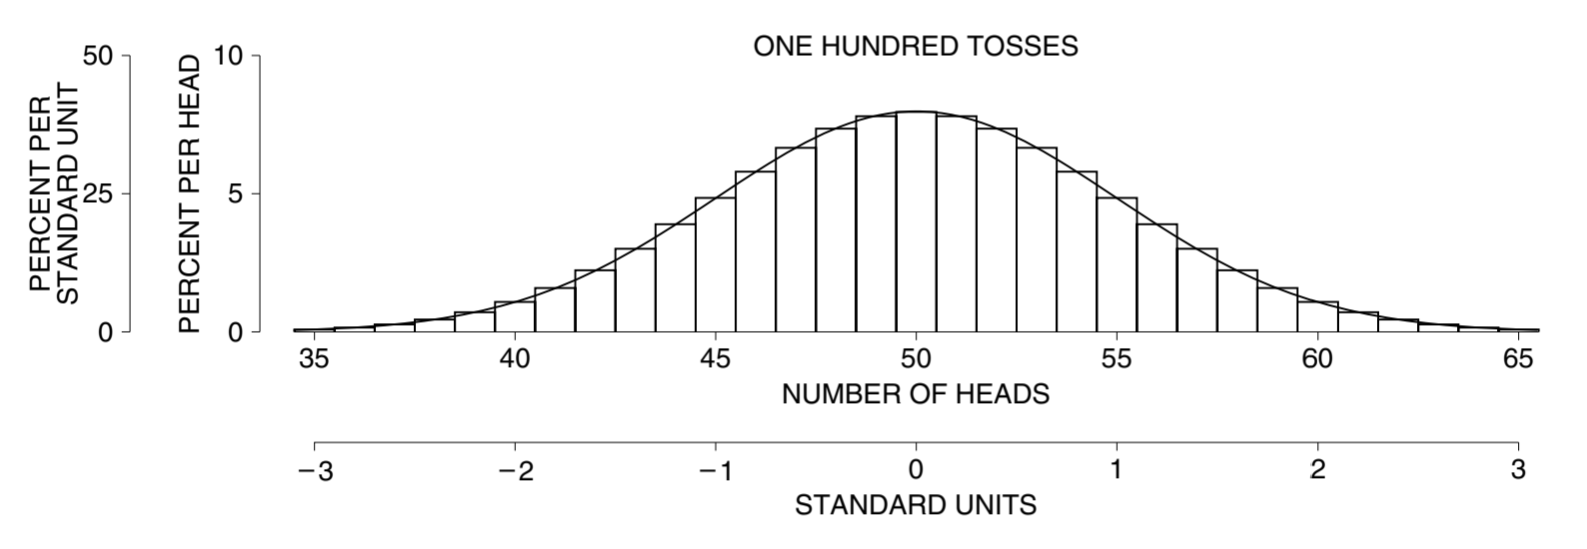

## 第十九章：抽样调查

现实世界中，直接调查要研究的群体中的所有人往往是不切实际的。所以一般会从这群人中选择一部分人作为样本，然后通过样本的调查结果，推断整体的结果。

研究者通常会希望了解关于总体的一些数值数据，这些数值数据被称为参数。通常这些参数没法精确统计到，只能通过样本进行估算。

换言之，调查者可以准确知道的是样本的统计数据，想了解的是总体的参数。

在样本可以代表总体的时候，这种方式才是可行的，为了达到这个目标，一般在选取样本的时候需要考虑两点：

- 样本的选取方式

  如果样本的选取方式本身带有偏见，也就是说存在选择偏差，那么即使扩大样本数量也只不过是在更大范围内重复错误。如果被选取的样本拒绝参与调查，就需要注意未回应偏差的产生。还有一种应该避免的抽样方法是定额抽样，也就是说把总体抽象为多个维度，给每个维度一些样本额度，这种方式看似美好，但实际上，不论是抽象结果还是配额中的调查方式，都存在太多主观因素。好的抽样方法应该尽可能避免主观因素的引入。

- 引入随机性

  比如不放回地从总体中抽取一定数量的人群，这种方式也叫简单随机抽样。但是实践中，这种方式的成本可能很大，比如选举的民意调查，从上亿的名单中抽取几千人，然后让调查员寻访全国进行访谈。所以，调查一般会采用多阶段集群抽样的办法。具体而言，就是先对总体进行初步划分，比如把全国选民分成东西南北四个区域，然后在这四个区域内随机抽取一些人口聚集的城镇，再把这些城镇的人口划分为多个选区，再随机抽取一些选区，再把选取划分为多个小组，再随机抽取一些小组进行访谈。

  > 这类抽样通常遵循 PPS (Probability Proportional to Size) 原则，即人口越多的群，被抽中的概率越大，所以你会看到前面提到的过程中，把非人口聚集的城镇排除掉了。这种方法天然地利于捕捉“主流”或“多数”意见。对于那些居住在非传统人口中心、生活方式迥异的边缘群体，这种方法也确实存在物理上的遗漏或统计上的代表性不足。

  除了多阶段集群抽样外，还有别的复杂的抽样方法，但所有的方法都有一个特点：调查者只能遵循既定的随机过程选取样本，任何主观选择都不被允许。

判断可能有偏见，但随机是绝对公正的。

除此之外，整个调查过程中的每个环节都可能会引入偏差，且一定会引入随机误差。这里的偏差也叫非抽样误差，随机误差也叫抽样误差。

~~虽然我怀疑现实中很多调查都是先射箭再画靶，故意使用偏向性的样本得到带有目的性结论。~~

## 第二十章：抽样误差

可以用标准误差来衡量抽样误差的大小。

比如从 3091 个男性和 3581 个女性组成的群体中，随机抽取 100 人。问男性占比会是多少。

我们可以建立盒子模型，里面放 3091 个 1 和 3581 个 0，我们很容易知道期望值为 0.46，标准差用简算公式计算：$\sqrt{0.46 \times 0.54} \approx 0.5$。抽到的 100 人中，预期会有 46 个是男性，上下浮动 $\sqrt{100} \times 0.5 = 5$ 人。换算回百分数，预期会有 $46 \pm 5\%$ 的男性。$\text{SE for percentage} = \frac{\text{SE for numbers}}{\text{size of sample}}$。将样本大小增大 4 倍变成 400，则百分比标准误差预期会缩小大约 $\sqrt{4} = 2$ 倍。这是平方根定律的体现。

标准误差公式的计算结果对于有放回抽样来说是精确的，对于无放回抽样来说，只要样本数相对总体比较少，这些结果也是可以作为近似值的，虽然实际标准误差总是会更小一些。

对于无放回的抽样来说，百分比标准误差应该是 $\frac{\sigma}{\sqrt{n}} \times \sqrt{\frac{N - n}{N - 1}}$，这里的 $\sqrt{\frac{N - n}{N - 1}}$ 是修正系数。$N$ 是盒子容量，$n$ 是抽取次数。当盒子容量相对于抽取次数越来越多时，你会发现修正系数越来越接近 1。

这里的本质在于无放回抽样抽取到的信息量总是大于等于有放回抽样抽取到的信息量。无放回抽样消除了更多随机性。所以它更能代表总体。

我们可以假设一种极端情况，盒子里面只有 0 和 1 两张票，在有放回地抽样中，第一张是 0，第二张章可以是 0 或 1。而在无放回抽样中，第一张如果是 0，第二张必定是 1，反之亦然。

分别考虑两种情况下的均值和标准差的变化。对于有放回抽样，单次实验的均值可能是 0、0.5 或 1，标准差可能是 0 或 0.5；对于无放回抽样，单次实验的均值只会是 0.5，标准差只可能是 0.5。可以看到，无放回抽样的均值和标准差与总体完全一致，更能代表总体。从定义上讲，无放回抽样的 SE 约为 0.3536，有放回抽样的 SE 为 0。

但不论对于有放回抽样还是无放回抽样，随机误差的绝对大小都不会因为总体规模大小，也就是盒子容量的大小而发生改变。影响这个的只有样本大小，也就是抽取次数。

另外一种思考角度是，假设你有一瓶液体需要检测成分构成，只要这瓶液体的混合足够均匀，你就可以只取一滴液体来完成整瓶液体的成分检测。

## 第二十一章：百分比的准确性

然而，现实生活中，我们要解决的问题往往是：根据随机抽取到的 100 人，估算总体中男性占比是多少。

用盒子模型的话表述就是，我们有个盒子，不知道里面装了多少 1 和多少 0，只知道盒子容量。现在想根据从盒子里面抽取到的 100 张票估计盒子里面的数字比例。

按照上一章的思路，会卡在第一步，因为不知道盒子里面多少 0 和 1，所以没法确定期望值和标准差。

但事情是有转机的，我们已经知道，当样本数量足够多时，我们可以用样本的比例来估计未知的总体比例，进而在公式中计算盒子的标准差，并由此估算出标准误差。

但有一点需要澄清：根据样本计算出来的均值是观测值，算出来的标准误差代表这个观测值和未知的期望值之间的误差大小。而我们在上一章根据白盒计算出来的均值就是实际的期望值。

可以用样本计算出来的均值和标准误差定义置信区间和置信度：

- 总体百分比落在 $[\text{AVG} - \text{SE}, \text{AVG} + \text{SE}]$ 的可能性约为 68%
- 总体百分比落在 $[\text{AVG} - 2\text{SE}, \text{AVG} + 2\text{SE}]$ 的可能性约为 95%
- 总体百分比落在 $[\text{AVG} - 3\text{SE}, \text{AVG} + 3\text{SE}]$ 的可能性约为 99.7%

我们总是应该使用“大约”这样的字眼来描述置信区间，因为不论是抽样过程本身还是正态近似，都会引入随机误差。

对于伯努利问题，我们还可以这么表达：总体中大约 95% 的群体的内部比例在 $\text{AVG} \pm 2\text{SE}$ 范围内。

## 第二十二章：失业率案例

前两章的公式，只适用于简单随机抽样的样本，对于其他复杂抽样的样本，需要另行考虑。

以下是原因所在。从逻辑上讲，前两章中的所有流程都源自平方根定律（第 17 章）。当样本规模相对于总体规模较小的时候，进行简单随机抽样就几乎等同于从一个盒子里不放回地随机抽取——这是平方根定律所适用的基本情况。这里所说的“随机抽取”是其专业含义：在每个阶段，盒子里的每张票都必须有同等的被选中的机会。如果样本不是随机抽取的，平方根定律就不适用，并且可能会给出荒谬的答案。

比如，简单随机抽样假设每一次抽取是独立的。但在聚类抽样中（比如先选城市，再选街道，最后选住户），同一个街道的居民在就业情况、收入、受教育程度等方面往往具有相关性。这种相关性会导致：如果你套用简单随机抽样的公式来计算误差，你通常会低估真实的标准误差。因为聚类抽样获取的信息量往往不如同等样本量的简单随机抽样多。

在现实世界的社会调查中，几乎没有真正的简单随机抽样。如果你用前几章学到的简单盒子模型去分析 CPS 数据，你得到的置信区间会太窄，从而给出过于乐观的精确度。

再次强调：技术上的操作不能取代对数据产生过程的理解。

## 第二十三章：平均值的准确性

思想很简单，要找出抽样平均值的标准误差，只需先求出总和的标准误差，然后将其除以抽样次数即可。

- $\text{sum of 25 draws} = 100 \pm 10 or so$
- $\text{average of 25 draws} = \frac{10}{25} \pm \frac{10}{25} or so$

当抽样次数足够多时，再一次，可以拟合整天曲线。

当增抽取次数时，比如增加到 4 倍，总和标准误差绝对值会增加 4 倍，总和标准误差百分比和均值的标准误差绝对值会减少 $\sqrt{4} = 2$ 倍。

## 第二十四章：测量误差模型

SD 衡量观测值距离均值的平均误差（数据的广度）。SE 估计均值距离期望值的平均误差（结论的精度）。

对于后者，一般会以置信区间的形式给出，因为 SE 实际上是预测值。

这种方式只适用于盒子模型（简单随机抽样）。原因已经反复提及，因为这种模型下的概率曲线才符合正态分布（高斯分布）。

随机误差来自测量行为本身，与被测量对象没有关系。这句话的意思是说，你对同一个对象反复测量时，实际上也是在从一个误差盒子里面抽误差。最终的测量值等于抽到的误差加上实际值。实践中，如果已有的丰富的实验经验告诉我们标准差的值，那么使用同一套流程测量同类对象得到的标准差，都应该以之前得到的这个标准差为准。

比如，假设已有的数万次对 NB10 的测量结果得到的标准差为 6 微克，那么用同一套流程测量另一个 NB10 时，只要测量次数不多于以往，那么标准差就应该以这个 6 微克为准。

如果存在的话，SE 的值会包含偏差，这个值无法把偏差和随机误差准确区分开。

通过为数据建立一个明确的概率模型，统计推断就能得到合理的解释。没有模型，就没有推断。

## 第二十六章：显著性检验

实验结论是由于偶然误差导致的，还是另有原因？这个问题由显著性检验来回答。

零假设（虚无假设）认为观测值与预期值的差异是由于偶然因素造成的。而备择假设认为这个差异是真实存在的。

显著性检验时，会先假设零假设为真声称的期望值是正确的，然后用这个零假设期望值计算 z 分数：$z = \frac{\text{observed} - \text{expected}}{\text{SE}}$，这种方式叫 z 分数检验，z 分数代表观测偏离预期值的 SE 数量。z 值所指代的显著性水平，也叫 P 值。

![z_test](./img/z_test.png)

此处的 $\text{SE}$ 的计算需要注意，如果已知总体的 SD 那么用 $\sqrt{n} \times SD$ 计算即可，如果只知道样本的 SD 且样本的数量比较小（5~10），那么需要使用 $SD^+$ 作为总体 SD 的估计，再继续计算，后续的假设检验也应该相应使用对应自由度（$n - 1$）的 t 分布模型，而不是高斯模型。

这里所观察到的显著性水平指的是出现与观测值一样极端（或更极端）的测试统计值的概率。该概率是基于原假设正确的前提下计算得出的。这个概率越小，就越能有力地反驳原假设。

P 值并非零假设正确的概率，$P$ 值是在假设零假设为真的前提下，观察到当前数据（或更极端数据）出现的概率。统计检验采用的是反证法逻辑。我们发现某个现象在“偶然”的情况下极难发生（$P$ 值很小），所以我们才怀疑并拒绝“偶然”这个解释，转而支持备择假设。

P 值是为了推翻零假设而存在的，所以 P 值越小越显著，一般认为，P 值低于 5% 才具有统计学意义，低于 1% 则认为是高度显著。

所有的加和检验都遵循这些步骤：

1. 根据数据的盒子模型，建立零假设
2. 计算一个数值来衡量观测到的数据与零假设（预期情况）之间的偏离程度，这个数值可以是：z 分数、t 分数、卡方值等
3. 计算观测到显著性水平，也就是 P 值

对于伯努利问题，比如分类计数，一般会选择 z 分数检验。

## 第二十七章：深入均值检验

两个量差值的期望值，等于两个量期望值的差值。

两个独立变量之间的标准误差为 $\sqrt{\text{SE}_a^2 + \text{SE}_b^2}$，对于存在依赖关系的两个变量，这个公式是不适用的。

假设有两个见到那随机样本，零假设是关于这两个样本均值的差异，适当的检验方式是：$$ z = \frac{\text{观测差异} - \text{期望差异}}{\text{差异的 SE}} $$

这种检验方式也叫两样本 z 检验。

双样本 z 检验也可用于比较实验中的治疗组与对照组的平均值或率。假设有一个票箱，每张票上有两个数字：一个显示对治疗 A 的反应，另一个显示对治疗 B 的反应。对于每张票，只能观察到这两个数字中的一个。

从箱子中随机抽取若干张票（无放回抽样），并观察它们对治疗 A 的反应。接着，从剩余的票中随机抽取第二组样本（无放回抽样），观察它们对治疗 B 的反应。两个样本平均值之差的标准误（SE）可以通过以下方式进行保守估计：：

1. 按照有放回抽样的方式计算平均值的标准误差；
2. 将这些标准误差合并起来，仿佛这两个样本是相互独立的。

由于在现实实验中，同一个人（同一张票）不能同时接受两种治疗，因此两个样本之间实际上存在负相关性（因为是从同一个有限总体中无放回抽取的）。直接使用独立样本的公式计算出的标准误通常会比实际的标准误大，因此被称为“保守”估计。但是前面可以忽略有限总体修正系数，直接按有放回抽样高估 SE。使得两个估计的误差相抵消。

## 第二十八章：卡方检验

对于伯努利问题，类别只有二项，可以用 z 检验做，但是对于超过两类的分类计数问题，一般会用卡方检验。

卡方值的计算公式为 $$\chi^2 = \text{sum of } \frac{(\text{observed frequency} - \text{expected frequency})^2}{\text{expected frequency}}$$

当模型已完全确定（即无需从数据中估计任何参数时），自由度 = 模型项数 - 1 。

所观察到的显著性水平 P 可以近似看作是 $\chi^2$ 曲线中观察值右侧的面积。该显著性水平表示模型产生与实际观测频率相差与当前情况一样大（甚至更大）的频率的概率，其中 $\chi^2$ 用于衡量这种差异的大小。但是，如果是为了检查数据造假，一般会用左侧面积作为 P 值。

如果多个实验是独立进行的，那么这些实验的自由度和卡方值可以相加。

另外，卡方检验还可以用于判断两变量是否独立。

## 第二十九章：深入显著性检验

一项测试的 P 值很大程度上取决于样本量的大小，样本量足够大的情况下，即使很小的差异也有可能呗误判为具有统计学意义，样本量很小的情况下，很多具有统计学意义的差异可能会被漏。

显著性检验不会检查实验设计是否合理，零假设被推翻时，也不会告诉你偏差到底出在哪里。

如果你可以拿到整体的所有数据，那么显著性检验没有意义，因为不存在抽样导致的偶然误差的空间。